## Case - Employee Score vs. Employee Background


### Background


A company is interested in explaining how certain factors relate to performance. The HR department is building regression models, but needs to make it in a way that's easily explainable to upper management.

The HR department is especially interested in explaining variation of employee score in terms of experience, employee work hours and degree

- We need to import library and function that need to run the code in this notebook to:
    - load data
    - doing simulation
    - drawing graph and other visualization

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Model fitting
import statsmodels.formula.api as smf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
emp = pd.read_csv('employee_performance_dataset.csv')
emp.head()

,emp_score,emp_degree,emp_experience,emp_hours,emp_age
0,84.0,1,30,7.0,58
1,100.0,1,29,11.6,48
2,88.2,1,4,9.9,56
3,82.0,1,29,8.8,51
4,69.9,1,24,5.2,23


### Overview of Data


- The overview for the descriptive statistics is given as follows.


In [3]:
emp.describe()

,emp_score,emp_degree,emp_experience,emp_hours,emp_age
count,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000
mean,79.867454,0.683333,15.259259,7.995185,38.984722
std,12.541678,0.465284,8.805889,2.337024,12.452159
min,51.900000,0.000000,0.000000,4.000000,18.000000
25%,69.700000,0.000000,8.000000,5.900000,28.000000
50%,78.300000,1.000000,16.000000,8.100000,39.000000
75%,90.725000,1.000000,23.000000,10.000000,50.000000
max,100.000000,1.000000,30.000000,12.000000,60.000000


- The average score the employee is about 79.
- The average employee experience is about 15 $\approx$ 16 years.
- The average employee work hours is approximately 8 hours per day, with a range of 4 to 12 hours.

In [4]:
emp.groupby(['emp_score'])[['emp_experience','emp_hours']].mean()

,emp_experience,emp_hours
emp_score,,
51.9,27.000000,5.600000
52.5,28.000000,4.400000
52.7,22.000000,4.200000
52.8,16.000000,7.300000
52.9,30.000000,8.100000
...,...,...
99.6,19.250000,10.650000
99.7,12.333333,10.600000
99.8,12.000000,11.425000


In [5]:
emp.groupby(['emp_degree'])[['emp_score']].mean()

,emp_score
emp_degree,
0,67.815205
1,85.452642


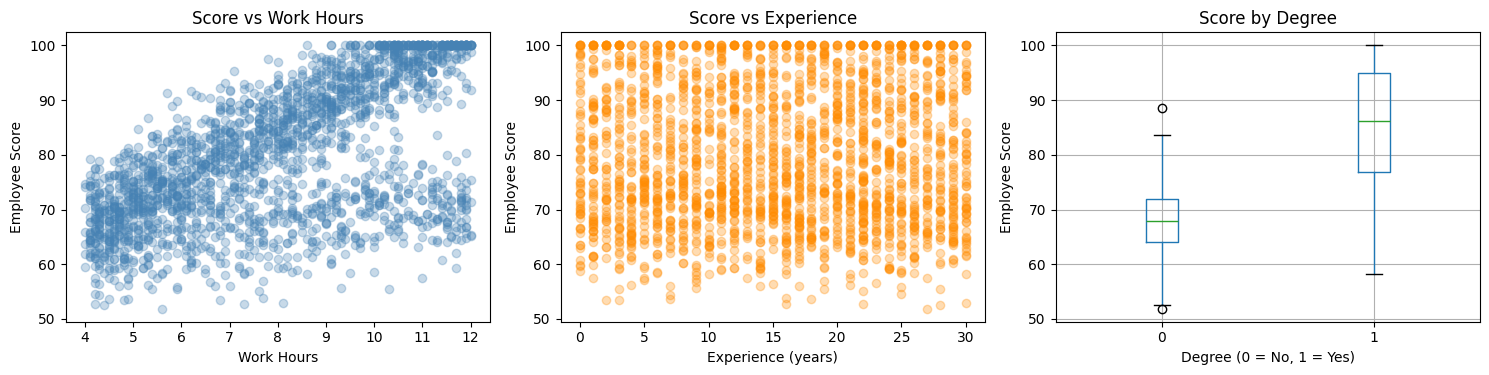

In [6]:
# Visualize relationships between predictors and emp_score
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# emp_hours vs emp_score
axes[0].scatter(emp['emp_hours'], emp['emp_score'], alpha=0.3, color='steelblue')
axes[0].set_xlabel('Work Hours')
axes[0].set_ylabel('Employee Score')
axes[0].set_title('Score vs Work Hours')

# emp_experience vs emp_score
axes[1].scatter(emp['emp_experience'], emp['emp_score'], alpha=0.3, color='darkorange')
axes[1].set_xlabel('Experience (years)')
axes[1].set_ylabel('Employee Score')
axes[1].set_title('Score vs Experience')

# emp_degree boxplot
emp.boxplot(column='emp_score', by='emp_degree', ax=axes[2])
axes[2].set_xlabel('Degree (0 = No, 1 = Yes)')
axes[2].set_ylabel('Employee Score')
axes[2].set_title('Score by Degree')
plt.suptitle('')
plt.tight_layout()
plt.show()


- On average, employees with a degree (85.45) got a higher score than those without a degree (67.82).

### Fit Linear Regression - Using a Continuous Variable

Use `ols` function under `statsmodels` library.

In [7]:
def print_coef_std_err(results):
    coef = results.params
    std_err = results.bse
    df = pd.DataFrame(data=np.transpose([coef, std_err]),
                      index=coef.index,
                      columns=["coef", "std err"])
    return df

In [8]:
# Create OLS model object
model = smf.ols("emp_score ~ emp_experience + emp_hours + emp_degree", emp)

# Fit the model
results = model.fit()

# Extract the results (Coefficient and Standard Error) to DataFrame
results_emp = print_coef_std_err(results)
results_emp

,coef,std err
Intercept,43.086003,0.548913
emp_experience,0.012323,0.014915
emp_hours,3.108732,0.056219
emp_degree,17.178322,0.282374


In [9]:
results.rsquared

np.float64(0.7636493559864679)

In [10]:
# Full model summary including p-values and confidence intervals
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:              emp_score   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                     2322.
Date:                Sat, 23 May 2026   Prob (F-statistic):               0.00
Time:                        23:15:00   Log-Likelihood:                -6969.3
No. Observations:                2160   AIC:                         1.395e+04
Df Residuals:                    2156   BIC:                         1.397e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         43.0860      0.549     78.

$$\text{emp\_score} = 43.08 + 0.012\text{emp\_experience} + 3.10 \text{emp\_hours} + 17.17 \text{emp\_degree}$$

- Based on the results above, we can see a relatively high standard error value for the emp_experience variable (0.0149), where this standard error value is even larger than the estimated coefficient value (0.0123). This indicates a very high level of uncertainty, so the amount of work experience does not provide sufficient or convincing information to explain the target variable.

- On the other hand, the overall performance of this model is quite good. The R-squared value is approximately 0.7636, meaning our model is able to explain 76.36% of the variance in the target variable using the existing predictor combination (emp_experience, emp_hours, and emp_degree).

- Therefore, let us proceed to interpret the coefficients of each predictor (such as the significant impact of working hours and education level) in order to understand more deeply how each variable relates to the target being analyzed.

### Coefficient Interpretation 

- The Intercept, $43.09$ is the predicted score for an employee with 0 years of experience, 0 working hours, and no degree. This is not a meaningful value since no employee in the dataset has these exact characteristics.

- The coefficient of emp_experience, the predictive difference comparing two employees who have the same working hours and degree level but differ by 1 year of experience is $0.012$.

- The coefficient of emp_hours, the predictive difference comparing two employees who have the same experience and degree level but differ by 1 working hour is $3.11$.

- The coefficient of emp_degree, the predictive difference comparing two employees who have the same experience and working hours but a different level/tier of degree is $17.18$.

That's the initial model, and we can definitely improve the interpretation upon it. Let's go!


### 1. Make intercept explain average score across employee degree instead of for no degree

- We can achieve this by standardizing Degree using 2 standard deviations

In [11]:
emp_degree = emp['emp_degree']

emp['z2_degree'] = (emp_degree - np.mean(emp_degree)) / (2*np.std(emp_degree))

In [12]:
# Create OLS model object
model = smf.ols("emp_score ~ emp_experience + emp_hours + z2_degree", emp)

# Fit the model
results = model.fit()

# Extract the results (Coefficient and Standard Error) to DataFrame
results_emp = print_coef_std_err(results)
results_emp

,coef,std err
Intercept,54.824523,0.517695
emp_experience,0.012323,0.014915
emp_hours,3.108732,0.056219
z2_degree,15.981893,0.262708


- Now the intercept is $54.82$ instead of the original $43.09$.

- The original intercept ($43.09$) reads as: "average score for employees with **no degree**, when other variables are 0".

- The improved model's intercept ($54.82$) reads as: "average score **across all degree levels** when other variables are 0".

### Coefficient Interpretation

In [13]:
# Centering emp_hours by subtracting its minimum value (4),
# so that the intercept reflects the predicted score when emp_hours equals 4 (the minimum)

emp['emp_hours_centered'] = emp['emp_hours'] - emp['emp_hours'].min()  # min = 4


# Centering emp_experience by subtracting its minimum value (0),
# so that the intercept reflects the predicted score when emp_experience equals 0 (the minimum)
emp['emp_experience_centered'] = emp['emp_experience'] - emp['emp_experience'].min()  # min = 0


In [14]:
# Create OLS model object
model = smf.ols("emp_score ~ emp_experience_centered + emp_hours_centered + z2_degree", emp)

# Fit the model
results = model.fit()

# Extract the results (Coefficient and Standard Error) to DataFrame
results_emp = print_coef_std_err(results)
results_emp

,coef,std err
Intercept,67.259452,0.343441
emp_experience_centered,0.012323,0.014915
emp_hours_centered,3.108732,0.056219
z2_degree,15.981893,0.262708


- The intercept, $64.19$ represents the predicted score for an employee who works the **minimum hours (4 hrs/day)**, has **0 years of experience**, and whose degree level is at the **average across all employees** (z2_degree = 0).

- The coefficient of emp_experience_centered, the predictive difference comparing two employees who have the same working hours and degree level but differ by 1 year of experience is $0.012$.

- The coefficient of emp_hours_centered, the predictive difference comparing two employees who have the same experience and degree level but differ by 1 working hour is $3.11$.

- The coefficient of z2_degree, the predictive difference comparing two employees who have the same experience and working hours but a different level/tier of degree is $15.98$.


### 2. Model Diagnostics – Residual Plot


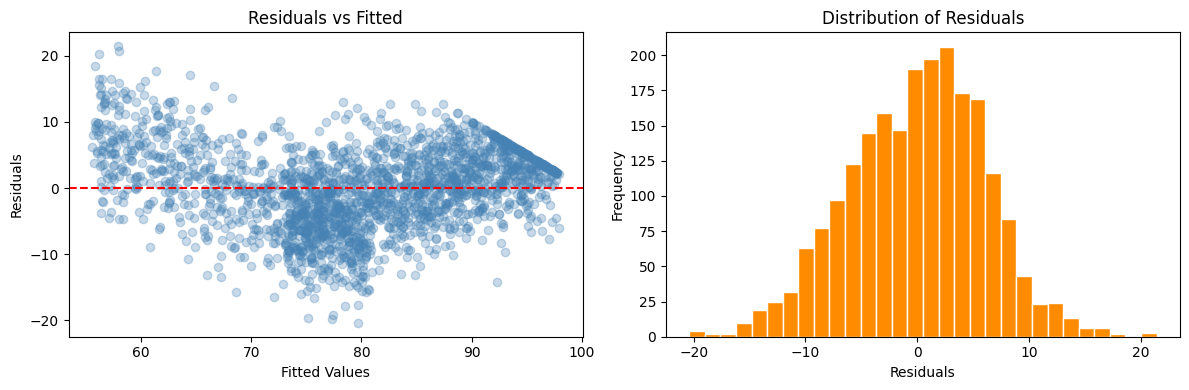

In [15]:
# Residual diagnostics for the final model
fitted = results.fittedvalues
residuals = results.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.3, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Histogram of residuals
axes[1].hist(residuals, bins=30, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()


### Model Diagnostics Interpretation

- **Residuals vs Fitted**: The residuals appear to be randomly scattered around the horizontal line at zero, with no obvious systematic pattern or funnel shape. This suggests that the **linearity** and **homoscedasticity** (constant variance) assumptions of OLS are reasonably satisfied.

- **Distribution of Residuals**: The histogram of residuals is approximately bell-shaped and centered near zero, which is consistent with the **normality of errors** assumption. There is a slight right skew, but it is not severe enough to cause major concern.

Overall, the model diagnostics indicate that the final OLS model is a reasonable fit and that the key regression assumptions are not seriously violated. The model can be used with confidence for interpretation and prediction within the range of the observed data.
